# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

山东是农业大省，对暴雨更敏感今年雨带主要在长江流域，广东虽是人口大省，但水患并不严重，关注率和西北省份相似

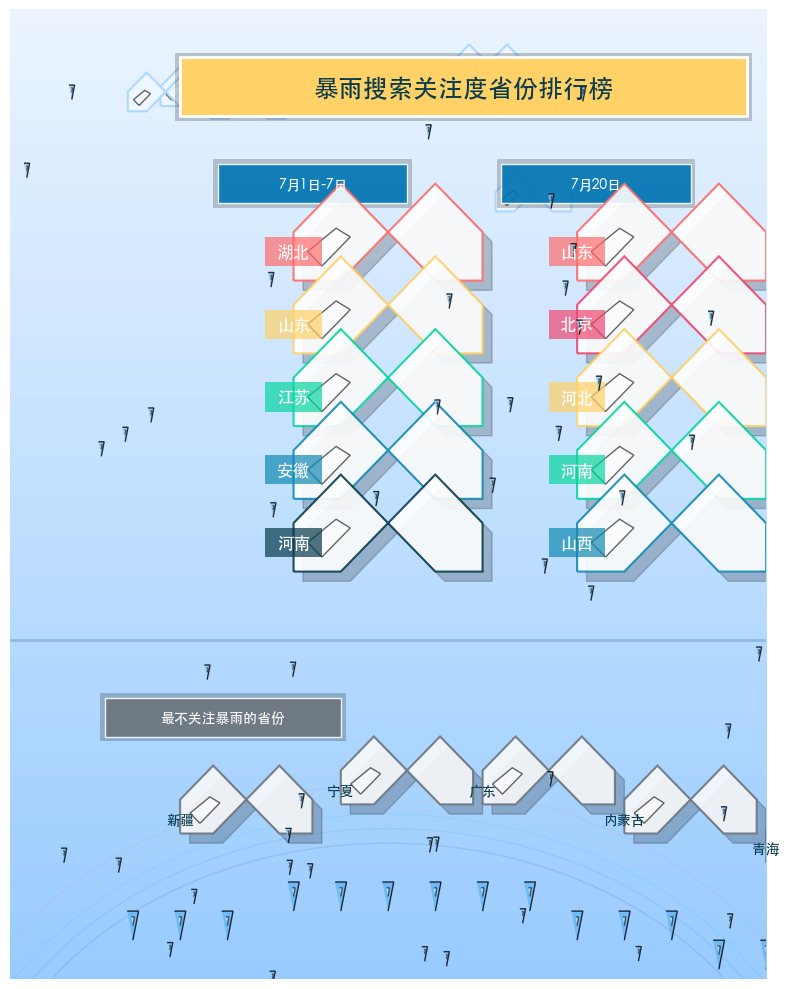

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, PathPatch, Path, Rectangle, Circle
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 定义绘制云朵形状的函数 - 增强版
def draw_cloud(ax, x, y, scale=1, color='#ffffff', edge_color='#a8d5ff', shadow=True):
    """绘制立体感云朵形状"""
    # 主云朵
    verts = [
        (0, 0), (1, 0), (2, 1), (3, 0), (4, 0),
        (4, 1), (3, 2), (2, 1), (1, 2), (0, 1),
        (0, 0)
    ]
    verts = np.array(verts) * scale + [x, y]
    path = Path(verts)
    
    # 添加阴影效果
    if shadow:
        shadow_verts = verts + [0.1, -0.1]
        shadow_path = Path(shadow_verts)
        shadow_patch = PathPatch(shadow_path, facecolor='black', alpha=0.2)
        ax.add_patch(shadow_patch)
    
    patch = PathPatch(path, facecolor=color, edgecolor=edge_color, linewidth=1.5, alpha=0.9)
    ax.add_artist(patch)
    
    # 添加高光
    highlight_verts = [
        (1, 0.5), (2, 1.5), (1.5, 1.8), (0.5, 1), (1, 0.5)
    ]
    highlight_verts = np.array(highlight_verts) * scale * 0.6 + [x, y]
    highlight_path = Path(highlight_verts)
    highlight_patch = PathPatch(highlight_path, facecolor='white', alpha=0.6)
    ax.add_artist(highlight_patch)
    
    return patch

# 定义绘制雨滴形状的函数 - 增强版
def draw_rain(ax, x, y, num_drops=3, scale=1, color='#64b5f6'):
    """绘制带渐变效果的雨滴"""
    drop_verts = [(-0.2, 0), (0.2, 0), (0, -1)]
    drop_verts = np.array(drop_verts) * scale
    
    for i in range(num_drops):
        dx = (i - (num_drops - 1) / 2) * 0.5
        drop_path = Path(drop_verts + [x + dx, y - 0.5])
        
        # 创建渐变效果
        drop_patch = PathPatch(drop_path, facecolor=color, alpha=0.8)
        ax.add_artist(drop_patch)
        
        # 添加雨滴反光
        highlight_verts = [(-0.05, -0.2), (0.05, -0.2), (0, -0.5)]
        highlight_verts = np.array(highlight_verts) * scale
        highlight_path = Path(highlight_verts + [x + dx, y - 0.5])
        highlight_patch = PathPatch(highlight_path, facecolor='white', alpha=0.6)
        ax.add_artist(highlight_patch)

# 定义绘制彩虹效果的函数
def draw_rainbow(ax, x, y, width, height):
    """绘制背景彩虹效果"""
    colors = ['#ff6b6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c']
    for i, color in enumerate(colors):
        arc = Arc((x, y), width - i*0.3, height - i*0.3, 
                  theta1=0, theta2=180, color=color, alpha=0.1)
        ax.add_artist(arc)

# 创建画布 - 增加渐变背景
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 8)
ax.set_ylim(0, 10)
ax.axis('off')

# 创建渐变色背景
x = np.linspace(0, 8, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)
Z = Y

cmap = LinearSegmentedColormap.from_list('sky_gradient', ['#e6f2ff', '#b3d9ff', '#80bfff'])
im = ax.imshow(Z, cmap=cmap, extent=[0, 8, 0, 10], alpha=0.8, aspect='auto')

# 添加背景彩虹
draw_rainbow(ax, 4, -2, 10, 8)

# 绘制装饰性小云
for i in range(5):
    x_pos = np.random.uniform(0.5, 7.5)
    y_pos = np.random.uniform(7, 9.5)
    draw_cloud(ax, x_pos, y_pos, scale=0.2, color='#f0f8ff', shadow=False)

# 绘制标题区域 - 增强立体感（去掉左侧圆形及数字5相关代码）
# 右侧标题条 - 添加阴影和渐变
title_rect_bg = Rectangle((1.75, 8.85), 6.1, 0.7, facecolor='black', alpha=0.2)
ax.add_artist(title_rect_bg)
title_rect = Rectangle((1.8, 8.9), 6, 0.6, facecolor='#ffd166', edgecolor='white', linewidth=2)
ax.add_artist(title_rect)
ax.text(4.8, 9.2, '暴雨搜索关注度省份排行榜', fontsize=18, color='#073b4c', 
        ha='center', va='center', fontweight='bold')

# 绘制两个时间段的标题 - 添加圆角和立体感
def draw_fancy_rect(ax, x, y, width, height, color, text, font_size=10):
    """绘制带圆角和立体感的矩形标题"""
    rect_bg = Rectangle((x-0.05, y-0.05), width+0.1, height+0.1, 
                        facecolor='black', alpha=0.2, edgecolor='none')
    ax.add_artist(rect_bg)
    
    rect = Rectangle((x, y), width, height, facecolor=color, 
                    edgecolor='white', linewidth=1, alpha=0.9)
    ax.add_artist(rect)
    
    ax.text(x + width/2, y + height/2, text, fontsize=font_size, 
            color='white', ha='center', va='center', fontweight='bold')

draw_fancy_rect(ax, 2.2, 8.0, 2, 0.4, '#0077b6', '7月1日-7日')
draw_fancy_rect(ax, 5.2, 8.0, 2, 0.4, '#0077b6', '7月20日')

# 绘制分隔线
divider = plt.Line2D([0, 8], [3.5, 3.5], color='#003e7e', alpha=0.2, linewidth=2)
ax.add_artist(divider)

# 绘制 7月1日-7日 省份云朵 - 添加渐变颜色
period1_provinces = ['湖北', '山东', '江苏', '安徽', '河南']
period1_colors = ['#ff6b6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c']
y_pos1 = np.linspace(7.2, 4.2, 5)

for i, (prov, color) in enumerate(zip(period1_provinces, period1_colors)):
    draw_cloud(ax, 3, y_pos1[i], scale=0.5, color='#ffffff', edge_color=color)
    # 添加省份名称背景
    name_bg = Rectangle((2.7, y_pos1[i]+0.15), 0.6, 0.3, facecolor=color, alpha=0.7, edgecolor='none')
    ax.add_artist(name_bg)
    ax.text(3, y_pos1[i] + 0.3, prov, fontsize=12, color='white', 
            ha='center', va='center', fontweight='bold')

# 绘制 7月20日 省份云朵 - 添加渐变颜色
period2_provinces = ['山东', '北京', '河北', '河南', '山西']
period2_colors = ['#ff6b6b', '#ef476f', '#ffd166', '#06d6a0', '#118ab2']
y_pos2 = np.linspace(7.2, 4.2, 5)

for i, (prov, color) in enumerate(zip(period2_provinces, period2_colors)):
    draw_cloud(ax, 6, y_pos2[i], scale=0.5, color='#ffffff', edge_color=color)
    # 添加省份名称背景
    name_bg = Rectangle((5.7, y_pos2[i]+0.15), 0.6, 0.3, facecolor=color, alpha=0.7, edgecolor='none')
    ax.add_artist(name_bg)
    ax.text(6, y_pos2[i] + 0.3, prov, fontsize=12, color='white', 
            ha='center', va='center', fontweight='bold')

# 绘制“最不关注暴雨的省份”标题
draw_fancy_rect(ax, 1, 2.5, 2.5, 0.4, '#6c757d', '最不关注暴雨的省份', font_size=10)

# 绘制最不关注省份（带雨滴） - 增强视觉效果
least_provinces = [('新疆', 1.8, 1.5, 3), ('宁夏', 3.5, 1.8, 3), 
                   ('广东', 5, 1.8, 3), ('内蒙古', 6.5, 1.5, 3), ('青海', 8, 1.2, 3)]

for i, (prov, x, y, drops) in enumerate(least_provinces):
    draw_cloud(ax, x, y, scale=0.35, color='#f8f9fa', edge_color='#6c757d')
    # 添加省份名称
    ax.text(x, y + 0.15, prov, fontsize=10, color='#073b4c', 
            ha='center', va='center', fontweight='bold')
    # 添加雨滴
    draw_rain(ax, x, y - 0.3, num_drops=drops, scale=0.3, color='#64b5f6')

# 添加装饰性雨滴背景
for _ in range(50):
    x_pos = np.random.uniform(0, 8)
    y_pos = np.random.uniform(0, 10)
    draw_rain(ax, x_pos, y_pos, num_drops=1, scale=0.15, color='#90caf9')

plt.tight_layout()
plt.show()

18岁以下，25-34岁 这两个年龄段对暴雨关注明显上扬。除了苦逼上班族之外，中小学生放暑假，暴雨对他们外出游玩影响较大

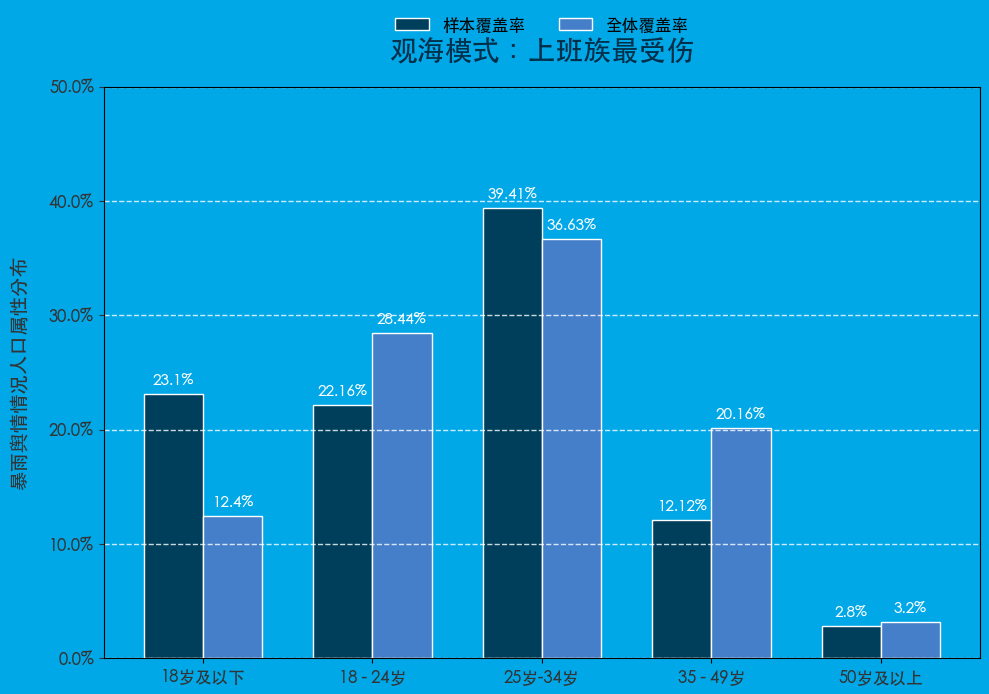

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 整理数据
age_groups = ["18岁及以下", "18 - 24岁", "25岁-34岁", "35 - 49岁", "50岁及以上"]
sample_coverage = [23.1, 22.16, 39.41, 12.12, 2.8]  # 样本覆盖率数据
total_coverage = [12.4, 28.44, 36.63, 20.16, 3.2]  # 全体覆盖率数据

x = np.arange(len(age_groups))  # x轴刻度位置
width = 0.35  # 柱状图宽度

# 创建画布和子图，优化画布大小适配
fig, ax = plt.subplots(figsize=(10, 7))
# 设置整体背景色，贴近原图蓝色
fig.set_facecolor('#00a8e8')
ax.set_facecolor('#00a8e8')

# 绘制样本覆盖率柱状图，调整颜色更柔和
rects1 = ax.bar(
    x - width/2, 
    sample_coverage, 
    width, 
    label='样本覆盖率', 
    color='#003f5c',
    edgecolor='white',  # 增加白色描边区分柱形
    linewidth=1
)
# 绘制全体覆盖率柱状图，调整颜色更柔和
rects2 = ax.bar(
    x + width/2, 
    total_coverage, 
    width, 
    label='全体覆盖率', 
    color='#457fca',
    edgecolor='white',  # 增加白色描边区分柱形
    linewidth=1
)

# 定制标题样式
ax.set_title(
    '观海模式：上班族最受伤', 
    fontsize=20, 
    fontweight='bold', 
    color='#002f4a',  # 深色标题更醒目
    pad=20  # 增加标题与图表间距
)
ax.set_ylabel(
    '暴雨舆情情况人口属性分布', 
    fontsize=14, 
    color='#333333',
    labelpad=15  # 增加y轴标签与图表间距
)

# 定制x轴刻度标签样式
ax.set_xticks(x)
ax.set_xticklabels(
    age_groups, 
    fontsize=12, 
    color='#333333',
    rotation=0  # 保持水平显示
)

# 优化y轴刻度，显示百分比更清晰
ax.set_ylim(0, 50)  # 合理设置y轴范围
ax.yaxis.set_major_formatter('{x}%')  # 直接显示百分比样式（需 matplotlib 3.3+）
ax.tick_params(axis='y', labelsize=12, colors='#333333')

# 优化数据标签样式
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height}%',
            xy=(rect.get_x() + rect.get_width()/2, height),
            xytext=(0, 5),  # 调整标签位置，避免遮挡
            textcoords='offset points',
            ha='center', 
            va='bottom',
            fontsize=11,
            color='white',  # 白色标签更醒目
            fontweight='bold'
        )

autolabel(rects1)
autolabel(rects2)

# 定制图例样式，放在图表上方
legend_elements = [
    Patch(facecolor='#003f5c', edgecolor='white', label='样本覆盖率'),
    Patch(facecolor='#457fca', edgecolor='white', label='全体覆盖率')
]
ax.legend(
    handles=legend_elements,
    loc='upper center',  # 图例位置
    bbox_to_anchor=(0.5, 1.15),  # 微调图例位置到图表上方
    ncol=2,  # 图例分两列显示
    fontsize=12,
    frameon=False  # 去掉图例边框
)

# 添加网格线，增强可读性
ax.grid(
    axis='y', 
    color='white', 
    linestyle='--', 
    alpha=0.8,
    linewidth=1
)

# 优化整体布局
plt.tight_layout()
# 显示图表
plt.show()

搜索指数人群画像显示，吃货、家庭主妇、数码控更关注暴雨，在“逛吃逛吃”组成的生活中，他们最关心暴雨带来的出行不便。
而游戏、理财用户主要宅在家，对暴雨关注度明显较低

/var/folders/54/bbrbnf8953d7z0fzwhskm0b00000gn/T/ipykernel_76031/1296113680.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues', 12)


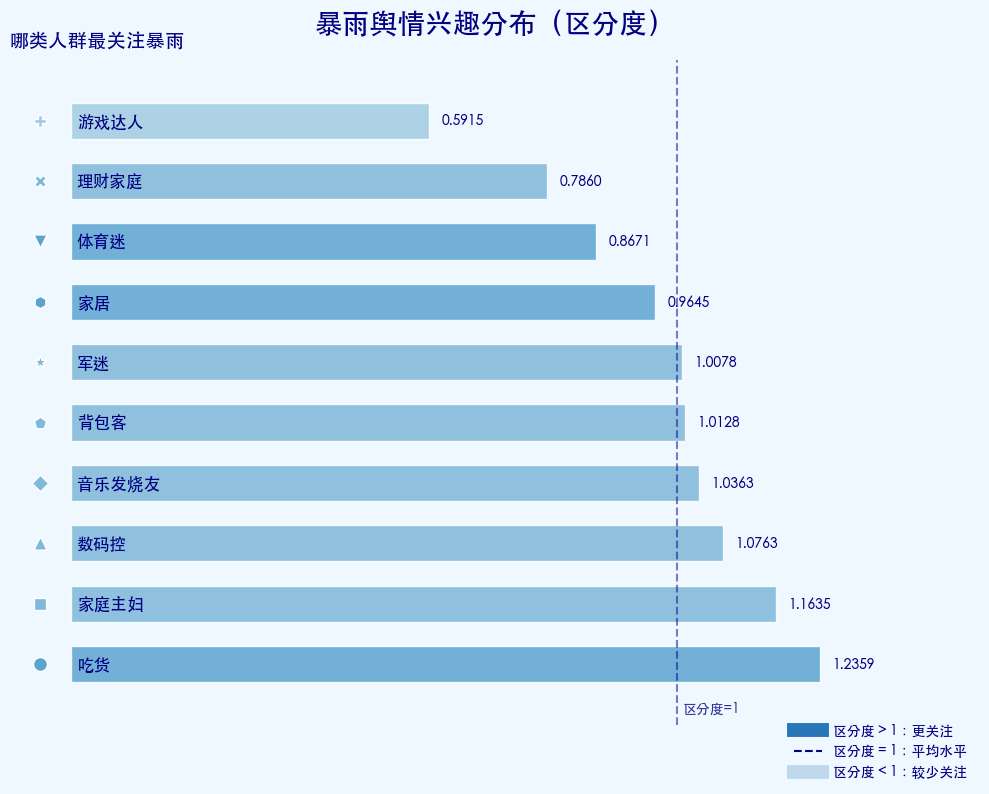

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# 数据
groups = ["吃货", "家庭主妇", "数码控", "音乐发烧友", "背包客", 
          "军迷", "家居", "体育迷", "理财家庭", "游戏达人"]
values = [1.2359, 1.1635, 1.0763, 1.0363, 1.0128, 
          1.0078, 0.9645, 0.8671, 0.7860, 0.5915]

# 符号映射（matplotlib 内置标记）
markers = ['o', 's', '^', 'D', 'p', '*', 'h', 'v', 'X', 'P']
marker_sizes = [100, 80, 90, 70, 85, 95, 80, 90, 75, 85]

# 创建画布
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f0f8ff")
ax.set_facecolor("#f0f8ff")

# 绘制柱状图（使用渐变色）
cmap = plt.cm.get_cmap('Blues', 12)
for i, (value, group) in enumerate(zip(values, groups)):
    color_idx = int(value * 5) if value > 1 else int(value * 5) + 2
    color = cmap(color_idx)
    
    ax.barh(i, value, height=0.6, color=color, edgecolor='white', alpha=0.85)
    ax.text(value + 0.02, i, f"{value:.4f}", 
            ha="left", va="center", color='navy', fontsize=10, fontweight='bold')

# 设置标题
ax.set_title("暴雨舆情兴趣分布（区分度）", 
             fontdict={"fontsize":20, "fontweight":"bold", "color":"navy"},
             pad=20)
ax.text(0, 1.02, "哪类人群最关注暴雨", 
        transform=ax.transAxes, fontsize=14, color='navy')

# 添加符号和类别标签
for i, (group, marker, size) in enumerate(zip(groups, markers, marker_sizes)):
    color_idx = int(values[i] * 5) if values[i] > 1 else int(values[i] * 5) + 2
    color = cmap(color_idx)
    
    ax.scatter(-0.05, i, marker=marker, s=size, color=color, edgecolor='white', zorder=3)
    ax.text(0.01, i, group, fontsize=12, ha="left", va="center", 
            color='navy', fontweight='bold')

# 添加参考线（区分度=1）
ax.axvline(x=1, color='navy', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(1.01, -0.8, "区分度=1", fontsize=10, color='navy', alpha=0.8)

# 隐藏坐标轴
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 设置x轴范围
ax.set_xlim(-0.1, 1.5)
ax.set_ylim(-1, 10)

# 添加图例（向下移动）
legend_elements = [
    Line2D([0], [0], color=cmap(8), lw=10, label='区分度 > 1：更关注'),
    Line2D([0], [0], color='navy', linestyle='--', lw=1.5, label='区分度 = 1：平均水平'),
    Line2D([0], [0], color=cmap(3), lw=10, label='区分度 < 1：较少关注')
]
ax.legend(handles=legend_elements, 
          loc='lower right',  # 定位到右下角
          bbox_to_anchor=(1, -0.1),  # 向下移动10%的高度
          frameon=False, 
          fontsize=10, 
          labelcolor='navy')

# 添加网格线
ax.grid(axis='x', linestyle='--', alpha=0.3, color='lightblue')

plt.tight_layout()
plt.show()

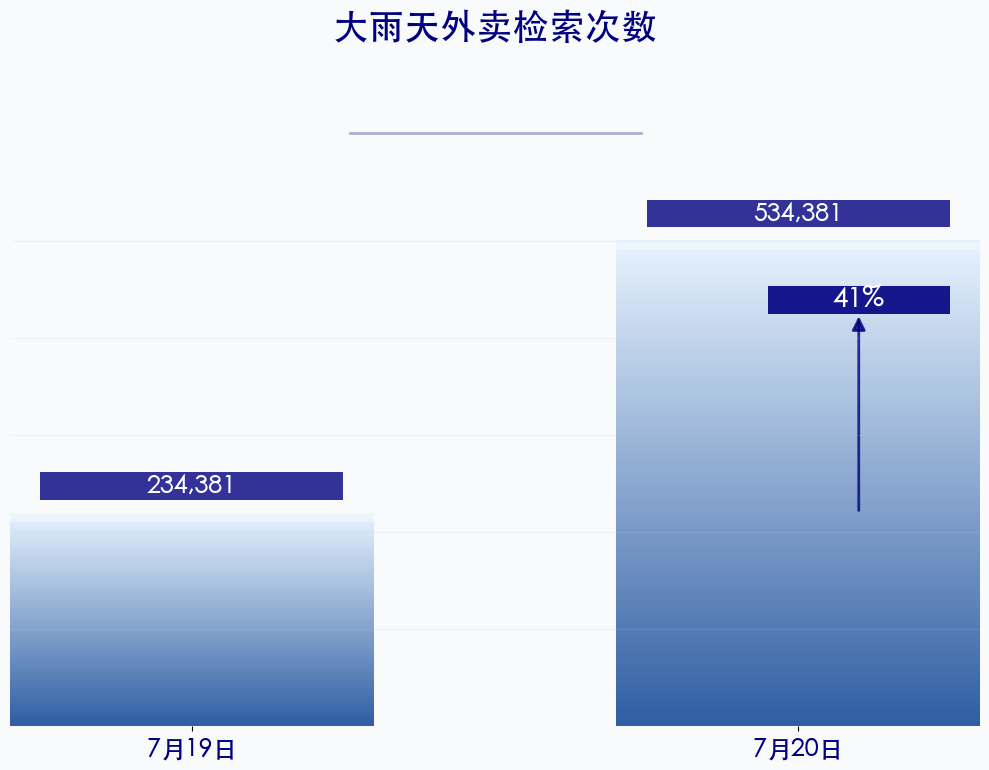

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.font_manager as fm

# 数据
dates = ["7月19日", "7月20日"]
searches = [234381, 534381]
increase = 41  # 增长率

# 创建自定义渐变色
colors = [(0.9, 0.95, 1), (0.1, 0.3, 0.6)]  # 从浅蓝到深蓝
custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors, N=100)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")

# 绘制背景网格
for y in np.linspace(0, max(searches), 6):
    ax.axhline(y, color='lightblue', alpha=0.15, linewidth=1)

# 绘制柱状图（带立体效果）
x_pos = np.arange(len(dates))
bar_width = 0.6

for i, (date, search) in enumerate(zip(dates, searches)):
    # 主柱状图（渐变填充）
    rect = Rectangle((i-bar_width/2, 0), bar_width, search, 
                    facecolor='none', edgecolor='none')
    ax.add_patch(rect)
    
    img = np.ones((100, 1)) * np.linspace(0.3, 1, 100).reshape(-1, 1)
    ax.imshow(img, aspect='auto', extent=[i-bar_width/2, i+bar_width/2, 0, search],
              cmap=custom_cmap, alpha=0.9, clip_path=rect)
    
    # 顶部高光
    top_highlight = Rectangle((i-bar_width/2, search-10000), bar_width, 10000, 
                             facecolor='white', alpha=0.3)
    ax.add_patch(top_highlight)
    
    # 数值标签（带阴影效果）
    label_bg = Rectangle((i-0.25, search+15000), 0.5, 30000, 
                        facecolor='navy', alpha=0.8, zorder=3)
    ax.add_patch(label_bg)
    
    ax.text(i, search+30000, f'{search:,}', 
            ha='center', va='center', color='white', fontsize=18, 
            fontweight='bold', zorder=4)

# 添加增长率指示（使用箭头和百分比符号）
class CustomArrow(FancyArrowPatch):
    def __init__(self, posA, posB, **kwargs):
        super().__init__(posA, posB, arrowstyle='-|>', 
                         mutation_scale=20, **kwargs)

arrow = CustomArrow((1.1, searches[0]), (1.1, searches[1]*0.85), 
                   color='navy', alpha=0.8, linewidth=2)
ax.add_patch(arrow)

# 增长率百分比标记
growth_bg = Rectangle((1.1-0.15, searches[1]*0.85), 0.3, 30000, 
                     facecolor='navy', alpha=0.9, zorder=3)
ax.add_patch(growth_bg)

ax.text(1.1, searches[1]*0.85+15000, f'{increase}%', 
        ha='center', va='center', color='white', fontsize=20, 
        fontweight='bold', zorder=4)

# 设置标题（带装饰线）
title = ax.set_title('大雨天外卖检索次数', 
                     fontdict={'fontsize':26, 'fontweight':'bold', 'color':'navy'},
                     pad=40, loc='center')

# 标题下的装饰线
line_start = 0.35
line_end = 0.65
ax.plot([line_start, line_end], [0.94, 0.94], transform=ax.transAxes, 
        color='navy', alpha=0.3, linewidth=2)

# 隐藏坐标轴
ax.set_xticks(x_pos)
ax.set_xticklabels(dates, color='navy', fontsize=18, fontweight='bold')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 设置y轴范围
ax.set_ylim(0, max(searches) * 1.3)

# 添加底部装饰条
bottom_bar = Rectangle((-0.5, -30000), 2.5, 30000, 
                      facecolor='navy', alpha=0.1)
ax.add_patch(bottom_bar)

# 优化布局
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # 为标题腾出空间
plt.show()